# Extracting data from website

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/131.0.0.0 Safari/537.36"
}

results = []

for jobs in job_url:  # job_url is your list of posting URLs
    response = requests.get(jobs, headers=headers, timeout=10)
    if response.status_code != 200:
        # print(f"Skipped {jobs}")
        continue

    soup = BeautifulSoup(response.content, "html.parser")

    # --- Job Title ---
    job_title_tag = soup.find("h1")
    job_title = job_title_tag.get_text(strip=True) if job_title_tag else None

    # --- Employer ---
    employer = None
    employer_strong = soup.find("strong", string=lambda x: x and "Employer:" in x)
    if employer_strong:
        employer = employer_strong.parent.get_text(strip=True).replace("Employer:", "").strip()

    # --- Employer URL ---
    employer_url = None
    employer_url_strong = soup.find("strong", string=lambda x: x and "Employer URL:" in x)
    if employer_url_strong:
        link = employer_url_strong.find_next("a")
        employer_url = link["href"] if link else None

    # --- Posted Date ---
    posted_date = None
    posted_strong = soup.find("strong", string=lambda x: x and "Posted to IASSIST on:" in x)
    if posted_strong:
        posted_date = posted_strong.parent.get_text(strip=True).replace("Posted to IASSIST on:", "").strip()

    # --- Salary ---
    salary = None
# look for either "Salary" or "Benefits"
    comp_strong = soup.find("strong", string=lambda x: x and ("Salary" in x or "Benefits" in x))
    if comp_strong:
      next_p = comp_strong.parent.find_next_sibling("p")
      salary = next_p.get_text(strip=True) if next_p else None


    # --- Necessary Skills ---
    skills_text = None
    skills = []
    skills_label = soup.find("p", string=lambda x: x and "Necessary Skills:" in x)
    if skills_label:
        ul = skills_label.find_next_sibling("ul")
        if ul:
            for li in ul.find_all("li"):
                skills.append(li.get_text(strip=True))
    skills_text = "; ".join(skills) if skills else None

        # --- Job Location ---
    job_location = None
    location_strong = soup.find("strong", string=lambda x: x and "Job Location" in x)
    if location_strong:
        next_p = location_strong.find_parent().find_next_sibling("p")
        job_location = next_p.get_text(strip=True) if next_p else None


    # --- Preferred Skills ---
    preferred_text = None
    preferred = []
    preferred_label = soup.find("p", string=lambda x: x and "Preferred Skills:" in x)
    if preferred_label:
        ul = preferred_label.find_next_sibling("ul")
        if ul:
            for li in ul.find_all("li"):
                preferred.append(li.get_text(strip=True))
    preferred_text = "; ".join(preferred) if preferred else None

    edu_text = None
    edu = []

# Look for all <strong> tags that mention Required or Preferred Qualifications
    qual_headers = soup.find_all("strong", string=lambda x: x and ("Qualifications" in x))

    for header in qual_headers:
    # Get the next <ul> sibling after the header (may be wrapped in a <p>)
      next_ul = header.find_parent().find_next_sibling("ul")
      if next_ul:
        for li in next_ul.find_all("li"):
            edu.append(li.get_text(strip=True))

      edu_text = "; ".join(edu) if edu else None



    # Store results
    results.append({
        "Job Title": job_title,
        "Employer": employer,
        "Employer URL": employer_url,
        "Posted Date": posted_date,
        "Salary": salary,
        "Job Location":job_location,
        "Necessary Skills": skills_text,
        "Preferred Skills": preferred_text,
        "Education/Experience": edu_text,
        "Source URL": jobs
    })


In [ ]:
df = pd.DataFrame(results)

# Data Cleaning and Analysis


In [ ]:
df

,Job Title,Employer,Employer URL,Posted Date,Salary,Job Location,Necessary Skills,Preferred Skills,Education/Experience,Source URL
0,Data Services Specialist,Georgia State University,https://gsu.edu/,2025-07-03,"$68,900 – $81,750","Atlanta, GA",None,None,Ability in IBM SPSS Statistics software (both ...,https://iassistdata.org/jobs-repository/2025-0...
1,Assistant or Associate Business Information & ...,Colorado State University,https://colostate.edu/,2025-06-25,"Assistant Rank: $67,000-$74,000; Associate Ran...","Fort Collins, CO",None,None,Candidates must have ONE of the following educ...,https://iassistdata.org/jobs-repository/2025-0...
2,Social Science Librarian,Georgia State University,https://gsu.edu/,2025-06-25,"$61,100 - $72,600, dependent on experience, ed...","Atlanta, GA",None,None,Experience working in an academic library; Exp...,https://iassistdata.org/jobs-repository/2025-0...
3,Business and Social Sciences Librarian,"University of California, Berkeley",https://berkeley.edu/,2025-06-17,The UC academic salary scales set the minimum ...,"Berkeley, CA",None,None,Advanced degree.,https://iassistdata.org/jobs-repository/2025-0...
4,Manager of Commons Events & Programming,Princeton University,https://princeton.edu/,2025-06-14,"$87,000 to $96,000","Princeton, NJ",None,None,Bachelor’s degree; 3 years experience planning...,https://iassistdata.org/jobs-repository/2025-0...
...,...,...,...,...,...,...,...,...,...,...
961,Statistical Support Specialist,Yale University,http://www.yale.edu/,2005-05-06,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...
962,Numeric and Spatial Data Services Librarian,University of Michigan,http://www.lib.umich.edu/,2005-05-01,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...
963,Librarian for the Social Sciences,Harvard College Library,http://www.harvard.edu/,2005-03-30,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...
964,Tenure-track position: Data Librarian,"Leddy Library, University of Windsor",http://www.uwindsor.ca/library/leddy,2005-03-22,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...


In [ ]:
df['Posted Date'] = pd.to_datetime(df['Posted Date'], errors='coerce')

# Define the date range
start_date = '2010-01-01'
end_date = '2025-12-31'

# Filter rows where 'Date' is between start_date and end_date (inclusive)
filtered_df = df[(df['Posted Date'] >= start_date) & (df['Posted Date'] <= end_date)]

In [ ]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 867 entries, 0 to 866
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Job Title             867 non-null    object        
 1   Employer              867 non-null    object        
 2   Employer URL          855 non-null    object        
 3   Posted Date           867 non-null    datetime64[ns]
 4   Salary                114 non-null    object        
 5   Job Location          149 non-null    object        
 6   Education/Experience  268 non-null    object        
 7   Qualification         223 non-null    object        
 8   Skills                260 non-null    object        
 9   Source URL            867 non-null    object        
dtypes: datetime64[ns](1), object(9)
memory usage: 74.5+ KB


In [ ]:
filtered_df

,Job Title,Employer,Employer URL,Posted Date,Salary,Job Location,Education/Experience,Qualification,Skills,Source URL
0,Data Services Specialist,Georgia State University,https://gsu.edu/,2025-07-03,"$68,900 – $81,750","Atlanta, GA",Librarian Instructor – no experience required....,Librarian Instructor – no experience required....,Ability in IBM SPSS Statistics software (both ...,https://iassistdata.org/jobs-repository/2025-0...
1,Assistant or Associate Business Information & ...,Colorado State University,https://colostate.edu/,2025-06-25,"Assistant Rank: $67,000-$74,000; Associate Ran...","Fort Collins, CO",Candidates must have ONE of the following educ...,Candidates must have ONE of the following educ...,Demonstrated ability to explain and/or teach c...,https://iassistdata.org/jobs-repository/2025-0...
2,Social Science Librarian,Georgia State University,https://gsu.edu/,2025-06-25,"$61,100 - $72,600, dependent on experience, ed...","Atlanta, GA",Experience providing in-person or online instr...,Master’s degree in library/information science...,Experience providing in-person or online instr...,https://iassistdata.org/jobs-repository/2025-0...
3,Business and Social Sciences Librarian,"University of California, Berkeley",https://berkeley.edu/,2025-06-17,The UC academic salary scales set the minimum ...,"Berkeley, CA",Advanced degree.,Advanced degree.,None,https://iassistdata.org/jobs-repository/2025-0...
4,Manager of Commons Events & Programming,Princeton University,https://princeton.edu/,2025-06-14,"$87,000 to $96,000","Princeton, NJ",Bachelor’s degree; 3 years experience planning...,Bachelor’s degree; Excellent interpersonal and...,"3 years experience planning workshops, events,...",https://iassistdata.org/jobs-repository/2025-0...
...,...,...,...,...,...,...,...,...,...,...
862,Senior Data and Support Services Officer,UK Data Archive,http://www.data-archive.ac.uk/,2010-04-20,None,None,None,None,None,https://iassistdata.org/jobs-repository/2010-0...
863,Data Librarian (Librarian II or III),"University of Toronto Libraries (Toronto, ON, ...",http://www.library.utoronto.ca/home/,2010-04-14,None,None,None,None,None,https://iassistdata.org/jobs-repository/2010-0...
864,Data Librarian - Three Year Term,University of Saskatchewan,http://www.usask.ca,2010-02-02,None,None,None,None,None,https://iassistdata.org/jobs-repository/2010-0...
865,Repository Librarian,University of North Carolina at Chapel Hill,http://www.lib.unc.edu/,2010-01-05,None,None,None,None,None,https://iassistdata.org/jobs-repository/2010-0...


In [ ]:
pattern = r'research data librarian|data librarian|data managers|data curation librarian'

# Filter rows where 'Jo b Title' contains any of the keywords
filtered_jobs = filtered_df[filtered_df['Job Title'].str.contains(pattern, case=False, na=False)]

In [ ]:
filtered_jobs.info()

NameError: name 'filtered_jobs' is not defined

In [ ]:
filtered_jobs =filtered_jobs.drop(columns=["Necessary Skills", "Preferred Skills"])


In [ ]:
subset_df = filtered_jobs[["Education/Experience", "Salary", "Source URL", "Job Location"]].dropna(how="any")
subset_df = filtered_jobs[filtered_jobs['Education/Experience'].notnull()]

# Select the desired columns
result_df = subset_df[['Salary', 'Source URL', 'Job Location', 'Education/Experience']]

# Reset index if you want a clean DataFrame
result_df = result_df.reset_index(drop=True)

In [ ]:
result_df

,Salary,Source URL,Job Location,Education/Experience
0,"Minimum salary: LIB I: $76,403; LIB II: $79,72...",https://iassistdata.org/jobs-repository/2025-0...,"Toronto, CA","Master’s degree in library, archival or inform..."
1,This is an SEIU L888 represented position (Sal...,https://iassistdata.org/jobs-repository/2025-0...,"Boston, MA",Two or more years of demonstrated experience d...
2,"Minimum salary $60,000, final determination co...",https://iassistdata.org/jobs-repository/2024-1...,"Lawrence, KS",ALA-accredited master’s degree in Library/Info...
3,Appointment at the rank of Assistant Professor...,https://iassistdata.org/jobs-repository/2024-0...,"Knoxville, TN",ALA-accredited Master’s degree in Library/Info...
4,None,https://iassistdata.org/jobs-repository/2024-0...,"University Park, PA",Advanced degree in a relevant subject area (e....
5,None,https://iassistdata.org/jobs-repository/2023-1...,"San Diego, CA",Graduate degree from an ALA-accredited program...
6,Colorado State University is not just a workpl...,https://iassistdata.org/jobs-repository/2023-1...,"Fort Collins, CO",Master’s degree in library science from an ALA...
7,FA01 - Faculty,https://iassistdata.org/jobs-repository/2023-0...,"South Orange, NJ",MLS or MI from an ALA-accredited graduate prog...
8,FA01 - Faculty,https://iassistdata.org/jobs-repository/2023-0...,"South Orange, NJ",Master’s degree in Library and Information Sci...
9,None,https://iassistdata.org/jobs-repository/2022-0...,None,Basic understanding of academic or research li...


In [ ]:
# 1. Define the update mapping and drop list
update_map = {
    "https://iassistdata.org/jobs-repository/2023-12-18/": {"Salary": "$74,280 - $77,508", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2023-10-06/": {"Salary": "66,667-78,000", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2024-07-24_1/": {"Salary": "$65,000-$70,000", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2022-04-19-00749/": {"Salary": None, "Job Location": "FA01 - Faculty - South Orange, NJ"},
    "https://iassistdata.org/jobs-repository/2022-03-03-00732/": {"Salary": "$69,100 - $116,100", "Job Location": "Cambridge, MA"},
    "https://iassistdata.org/jobs-repository/2021-10-18-00705/": {"Salary": "$55,000-$85,000", "Job Location": "NY"},
    "https://iassistdata.org/jobs-repository/2021-04-16-00695-1/": {"Salary": "$72,367 - $92,613", "Job Location": "Toronto, CA"},
    "https://iassistdata.org/jobs-repository/2021-03-02-00687/": {"Salary": "$65,000 - $75,000", "Job Location": "Columbus, OH"},
    "https://iassistdata.org/jobs-repository/2020-09-17-00653/": {"Salary": "$48,000", "Job Location": "Logan, UT"},
    "https://iassistdata.org/jobs-repository/2019-07-08-00611/": {"Salary": "$48,000", "Job Location": "Ithaca, NY"},
    "https://iassistdata.org/jobs-repository/2018-12-13-00568/": {"Salary": "$76,603", "Job Location": "Ann Arbor, MI"},
    "https://iassistdata.org/jobs-repository/2018-10-30-00558/": {"Salary": "$47,428", "Job Location": "Knoxville, TN"},
    "https://iassistdata.org/jobs-repository/2017-11-29-00513/": {"Salary": None, "Job Location": "Edinburgh, UK"},
    "https://iassistdata.org/jobs-repository/2016-09-22-00428/": {"Salary": None, "Job Location": "College Station, TX"},
    "https://iassistdata.org/jobs-repository/2014-11-17-00286/": {"Salary": "$76,603", "Job Location": "Ann Arbor, MI"},
    "https://iassistdata.org/jobs-repository/2025-02-10/": {"Salary": "$65,226 - $86,816", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2024-12-12/": {"Salary": "$60,000", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2024-07-25/": {"Salary": "$63,000", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2025-03-19/": {"Salary": "$76,403 - $79,720", "Job Location": None}
}

drop_urls = [
    "https://iassistdata.org/jobs-repository/2017-05-18-00471/",
    "https://iassistdata.org/jobs-repository/2016-11-16-00444/",
    "https://iassistdata.org/jobs-repository/2012-04-05-00171/",
]

# 2. Update the original DataFrame in place
for url, updates in update_map.items():
    mask = filtered_df['Source URL'] == url
    if updates["Salary"] is not None:
        filtered_df.loc[mask, "Salary"] = updates["Salary"]
    if updates["Job Location"] is not None:
        filtered_df.loc[mask, "Job Location"] = updates["Job Location"]

# 3. Filter to rows with non-null Education/Experience
filtered_result_df = filtered_df[filtered_df['Education/Experience'].notnull()].copy()

# 4. Drop rows with specified Source URLs
filtered_result_df = filtered_result_df[~filtered_result_df['Source URL'].isin(drop_urls)]

# 5. Reset index if needed
filtered_result_df = filtered_result_df.reset_index(drop=True)


In [ ]:
filtered_result_df

,Job Title,Employer,Employer URL,Posted Date,Salary,Job Location,Necessary Skills,Preferred Skills,Education/Experience,Source URL
0,Data Services Specialist,Georgia State University,https://gsu.edu/,2025-07-03,"$68,900 – $81,750","Atlanta, GA",None,None,Ability in IBM SPSS Statistics software (both ...,https://iassistdata.org/jobs-repository/2025-0...
1,Assistant or Associate Business Information & ...,Colorado State University,https://colostate.edu/,2025-06-25,"Assistant Rank: $67,000-$74,000; Associate Ran...","Fort Collins, CO",None,None,Candidates must have ONE of the following educ...,https://iassistdata.org/jobs-repository/2025-0...
2,Social Science Librarian,Georgia State University,https://gsu.edu/,2025-06-25,"$61,100 - $72,600, dependent on experience, ed...","Atlanta, GA",None,None,Experience working in an academic library; Exp...,https://iassistdata.org/jobs-repository/2025-0...
3,Business and Social Sciences Librarian,"University of California, Berkeley",https://berkeley.edu/,2025-06-17,The UC academic salary scales set the minimum ...,"Berkeley, CA",None,None,Advanced degree.,https://iassistdata.org/jobs-repository/2025-0...
4,Manager of Commons Events & Programming,Princeton University,https://princeton.edu/,2025-06-14,"$87,000 to $96,000","Princeton, NJ",None,None,Bachelor’s degree; 3 years experience planning...,https://iassistdata.org/jobs-repository/2025-0...
...,...,...,...,...,...,...,...,...,...,...
238,Science Data & Engineering Librarian,"University of California, Berkeley",http://www.berkeley.edu/,2015-08-12,None,None,None,None,Significant coursework or library experience i...,https://iassistdata.org/jobs-repository/2015-0...
239,Data Services Librarian,Reed College,http://www.reed.edu/,2015-07-23,None,None,None,None,ALA-accredited master’s degree in library and ...,https://iassistdata.org/jobs-repository/2015-0...
240,Research Data Curation Librarian,University of Michigan,https://www.umich.edu/,2014-11-17,"$76,603","Ann Arbor, MI",None,None,ALA-accredited Master’s degree or an equivalen...,https://iassistdata.org/jobs-repository/2014-1...
241,Research Data Services Librarian,Cornell University,http://www.cornell.edu/,2014-07-21,None,None,None,None,Master’s degree in Library and Information Sci...,https://iassistdata.org/jobs-repository/2014-0...


In [ ]:
filtered_result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Job Title             243 non-null    object        
 1   Employer              243 non-null    object        
 2   Employer URL          243 non-null    object        
 3   Posted Date           243 non-null    datetime64[ns]
 4   Salary                102 non-null    object        
 5   Job Location          121 non-null    object        
 6   Necessary Skills      0 non-null      object        
 7   Preferred Skills      0 non-null      object        
 8   Education/Experience  243 non-null    object        
 9   Source URL            243 non-null    object        
dtypes: datetime64[ns](1), object(9)
memory usage: 19.1+ KB


In [ ]:
# Filter rows where 'Job Location' is not null
filtered_by_location = filtered_df[filtered_df['Job Location'].notnull()]

# Optional: reset index for clean DataFrame
filtered_by_location = filtered_by_location.reset_index(drop=True)


In [ ]:
filtered_by_location = filtered_by_location.drop(columns=["Necessary Skills", "Preferred Skills"])


In [ ]:
filtered_by_location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Job Title             161 non-null    object        
 1   Employer              161 non-null    object        
 2   Employer URL          161 non-null    object        
 3   Posted Date           161 non-null    datetime64[ns]
 4   Salary                88 non-null     object        
 5   Job Location          161 non-null    object        
 6   Education/Experience  121 non-null    object        
 7   Source URL            161 non-null    object        
dtypes: datetime64[ns](1), object(7)
memory usage: 10.2+ KB


In [ ]:
# filtered_by_location.head(25)
pattern = r'research data librarian|data librarian|data managers|data curation librarian'

# Filter rows where 'Job Title' contains any of the keywords
iassist_jobs = filtered_by_location[filtered_by_location['Job Title'].str.contains(pattern, case=False, na=False)]

In [ ]:
# Fill missing values in 'Salary' and 'Education/Experience' columns with 'not provided'
iassist_jobs['Salary'] = iassist_jobs['Salary'].fillna('not provided')
iassist_jobs['Education/Experience'] = iassist_jobs['Education/Experience'].fillna('not provided')

/tmp/ipython-input-105137696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iassist_jobs['Salary'] = iassist_jobs['Salary'].fillna('not provided')
/tmp/ipython-input-105137696.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iassist_jobs['Education/Experience'] = iassist_jobs['Education/Experience'].fillna('not provided')


In [ ]:
iassist_jobs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 6 to 160
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Job Title             24 non-null     object        
 1   Employer              24 non-null     object        
 2   Employer URL          24 non-null     object        
 3   Posted Date           24 non-null     datetime64[ns]
 4   Salary                24 non-null     object        
 5   Job Location          24 non-null     object        
 6   Education/Experience  24 non-null     object        
 7   Source URL            24 non-null     object        
dtypes: datetime64[ns](1), object(7)
memory usage: 1.7+ KB


In [ ]:
import pandas as pd

# Function to extract only the "skills" part
def extract_skills(text):
    if pd.isna(text):
        return None

    parts = text.split(";", 1)  # split into two parts only
    if len(parts) > 1:
        return parts[1].strip()  # everything after the first ";"
    return None  # no skills if no ";"

# Apply function to create new column
iassist_jobs["Skills"] = iassist_jobs["Education/Experience"].apply(extract_skills)


In [ ]:
iassist_jobs

,Job Title,Employer,Employer URL,Posted Date,Salary,Job Location,Education/Experience,Source URL,Min Salary,Skills
6,Data Librarian,University of Toronto,https://utoronto.ca/,2025-03-19,"$76,403 - $79,720","Toronto, CA","Master’s degree in library, archival or inform...",https://iassistdata.org/jobs-repository/2025-0...,76403.0,Demonstrated commitment to the values of inclu...
16,Research Data Librarian,Boston University,https://www.bu.edu/,2025-02-10,"$65,226 - $86,816","Boston, MA",Two or more years of demonstrated experience d...,https://iassistdata.org/jobs-repository/2025-0...,65226.0,Familiarity with one or more applications for ...
22,Research Data Librarian,University of Kansas,https://ku.edu/,2024-12-12,"$60,000","Lawrence, KS",ALA-accredited master’s degree in Library/Info...,https://iassistdata.org/jobs-repository/2024-1...,60000.0,ALA-accredited master’s degree in Library/Info...
41,Research Data Librarian,University of Tennessee,https://www.utk.edu/,2024-07-25,"$63,000","Knoxville, TN",ALA-accredited Master’s degree in Library/Info...,https://iassistdata.org/jobs-repository/2024-0...,63000.0,Familiarity with the research and data lifecyc...
42,Data Curation Librarian,Penn State University,https://www.psu.edu/,2024-07-24,"$65,000-$70,000","University Park, PA",Advanced degree in a relevant subject area (e....,https://iassistdata.org/jobs-repository/2024-0...,65000.0,Familiarity with identifying the needs of rese...
50,Digital Collections and Metadata Librarian,University of California Berkeley,https://www.berkeley.edu/,2024-05-24,not provided,"Berkeley, CA",not provided,https://iassistdata.org/jobs-repository/2024-0...,NaN,None
59,Research Data Librarian,Cornell University Library,https://library.cornell.edu/,2024-03-16,Relocation assistance may be provided.,"Ithaca, NY",not provided,https://iassistdata.org/jobs-repository/2024-0...,NaN,None
71,Social Science and Data Librarian,San Diego State University,https://www.sdsu.edu/,2023-12-18,"$74,280 - $77,508","San Diego, CA",Graduate degree from an ALA-accredited program...,https://iassistdata.org/jobs-repository/2023-1...,74280.0,Demonstrated early career librarian experience...
86,Research Data Librarian-Science Specialist,Colorado State University,https://www.colostate.edu/,2023-10-06,"66,667-78,000","Fort Collins, CO",Master’s degree in library science from an ALA...,https://iassistdata.org/jobs-repository/2023-1...,66667.0,a PhD in a data-intensive field; or a Master’s...
103,Business and Data Librarian,Seton Hall University,https://shu.edu/,2023-04-20,FA01 - Faculty,"South Orange, NJ",MLS or MI from an ALA-accredited graduate prog...,https://iassistdata.org/jobs-repository/2023-0...,NaN,A degree (undergraduate or graduate) in busine...


In [ ]:
iassist_jobs[["Salary"]]

,Salary
6,"$76,403 - $79,720"
16,"$65,226 - $86,816"
22,"$60,000"
41,"$63,000"
42,"$65,000-$70,000"
50,not provided
59,Relocation assistance may be provided.
71,"$74,280 - $77,508"
86,"66,667-78,000"
103,FA01 - Faculty


In [ ]:
iassist_jobs.to_csv("iassist_jobs.csv", index=False)

# GRAPHS

/tmp/ipython-input-1680081260.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iassist_jobs['Min Salary'] = iassist_jobs['Salary'].apply(extract_min_salary)


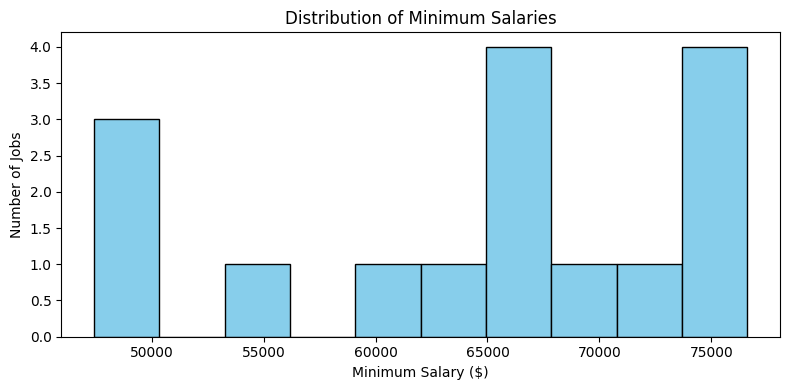

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Example: iassist_jobs is your DataFrame

def extract_min_salary(s):
    if pd.isnull(s):
        return None
    s = s.lower()
    # Treat common non-numeric entries as missing
    if 'not provided' in s or 'relocation' in s or 'faculty' in s:
        return None
    # Extract all numbers (digits) ignoring commas and dollar signs
    nums = re.findall(r'\$?(\d{2,6})', s.replace(',', ''))
    if nums:
        # Return the first number as minimum salary
        return int(nums[0])
    return None

# Apply extraction to Salary column
iassist_jobs['Min Salary'] = iassist_jobs['Salary'].apply(extract_min_salary)

# Drop rows where Min Salary is missing for plotting
salary_data = iassist_jobs['Min Salary'].dropna().astype(int)

# Plot histogram of minimum salaries
plt.figure(figsize=(8,4))
plt.hist(salary_data, bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Minimum Salaries')
plt.xlabel('Minimum Salary ($)')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()


/tmp/ipython-input-3992810533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iassist_jobs['State'] = iassist_jobs['Job Location'].apply(


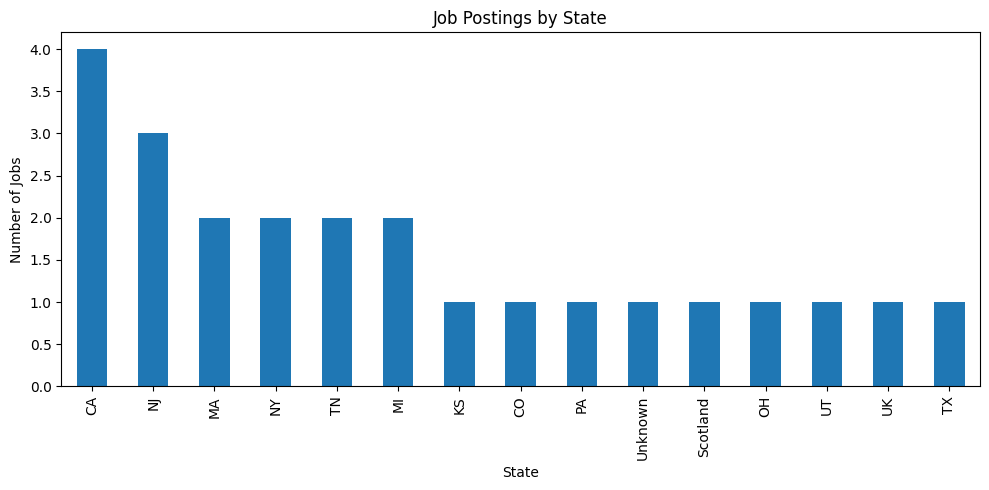

In [ ]:
# Extract state abbreviation from 'Job Location' (format: "City, ST")
iassist_jobs['State'] = iassist_jobs['Job Location'].apply(
    lambda x: x.split(',')[-1].strip() if pd.notnull(x) and ',' in x else 'Unknown'
)

# Plot 1: Job postings by state
state_counts = iassist_jobs['State'].value_counts()
plt.figure(figsize=(10,5))
state_counts.plot(kind='bar', title='Job Postings by State')
plt.xlabel('State')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()


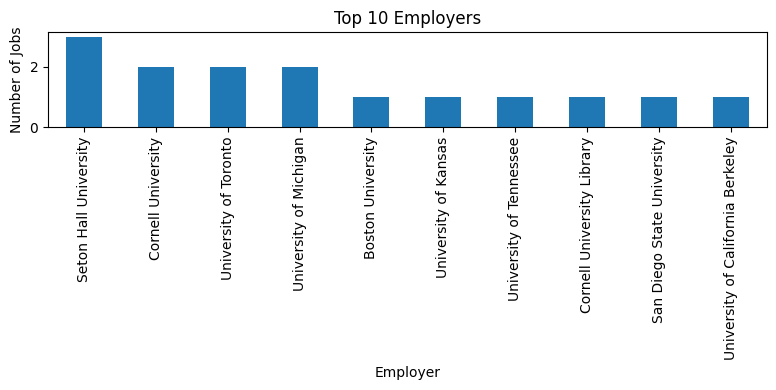

In [ ]:
# Plot 2: Top 10 Employers by number of job postings
top_employers = iassist_jobs['Employer'].value_counts().head(10)
plt.figure(figsize=(8,4))
top_employers.plot(kind='bar', title='Top 10 Employers')
plt.xlabel('Employer')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()


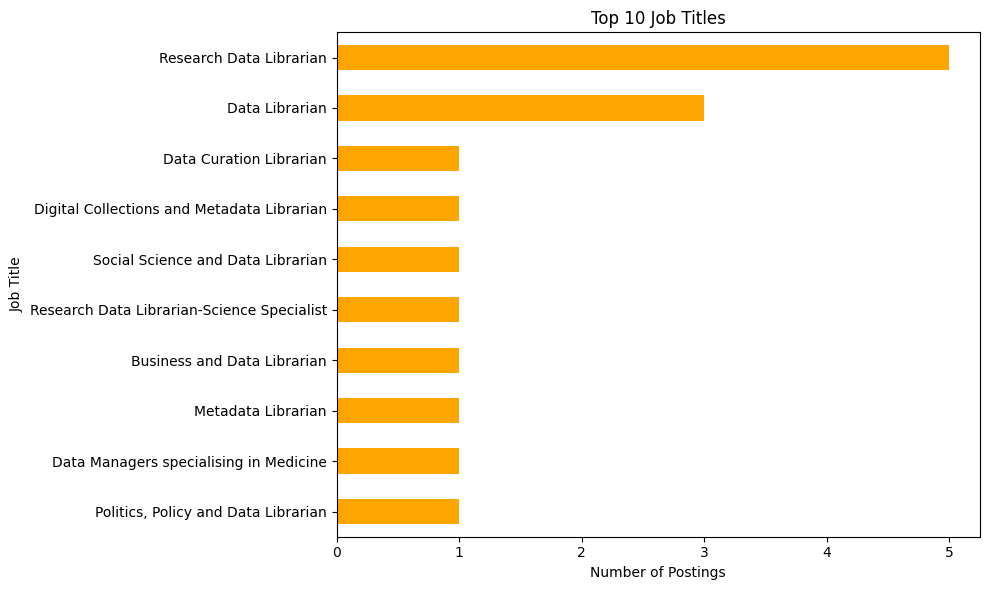

In [ ]:
import matplotlib.pyplot as plt

top_titles = iassist_jobs['Job Title'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_titles.plot(kind='barh', color='orange')
plt.title("Top 10 Job Titles")
plt.xlabel("Number of Postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

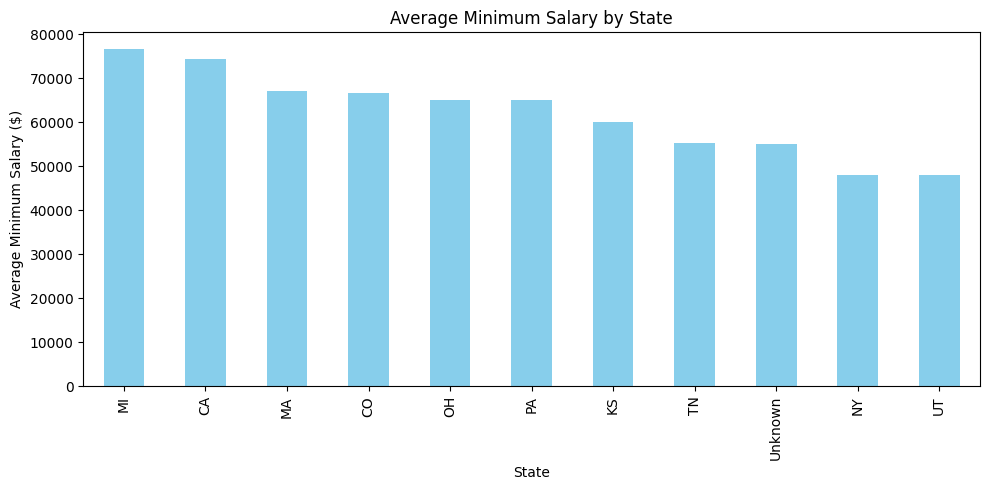

In [ ]:
import matplotlib.pyplot as plt

# Group by 'State' and calculate average minimum salary
avg_salary_by_state = iassist_jobs.groupby('State')['Min Salary'].mean().dropna()

# Plot average salary by state as a bar chart
plt.figure(figsize=(10,5))
avg_salary_by_state.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Average Minimum Salary by State')
plt.xlabel('State')
plt.ylabel('Average Minimum Salary ($)')
plt.tight_layout()
plt.show()


/tmp/ipython-input-219249401.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iassist_jobs['EduExp_Category'] = iassist_jobs['Education/Experience'].apply(extract_edu_exp)


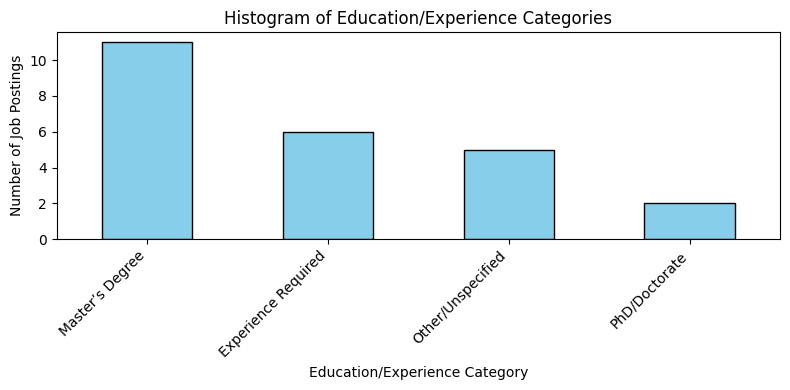

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: your DataFrame is iassist_jobs and it has a column 'Education/Experience'

# Step 1: Define a function to extract and categorize education/experience levels
def extract_edu_exp(text):
    if pd.isna(text):
        return 'Not Provided'
    text = text.lower()
    if 'phd' in text or 'doctorate' in text:
        return 'PhD/Doctorate'
    elif 'master' in text or 'msc' in text or 'ma ' in text or 'm.a.' in text or 'm.s.' in text:
        return 'Master’s Degree'
    elif 'bachelor' in text or 'ba ' in text or 'b.a.' in text or 'b.s.' in text or 'bs ' in text:
        return 'Bachelor’s Degree'
    elif 'associate' in text:
        return 'Associate Degree'
    elif 'experience' in text:
        return 'Experience Required'
    else:
        return 'Other/Unspecified'

# Step 2: Apply the function to create a new categorized column
iassist_jobs['EduExp_Category'] = iassist_jobs['Education/Experience'].apply(extract_edu_exp)

# Step 3: Plot the histogram (bar chart) of counts per category
plt.figure(figsize=(8,4))
iassist_jobs['EduExp_Category'].value_counts().plot(
    kind='bar', color='skyblue', edgecolor='black'
)
plt.title('Histogram of Education/Experience Categories')
plt.xlabel('Education/Experience Category')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Visual Data Succesfully extracted


# Rough Draft of various attempts to get data based on the goal of the project


In [ ]:
filtered_jobs.to_csv("./iassist_jobs.csv")

In [ ]:
iassist_jobs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 6 to 160
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Job Title             24 non-null     object        
 1   Employer              24 non-null     object        
 2   Employer URL          24 non-null     object        
 3   Posted Date           24 non-null     datetime64[ns]
 4   Salary                19 non-null     object        
 5   Job Location          24 non-null     object        
 6   Education/Experience  21 non-null     object        
 7   Source URL            24 non-null     object        
dtypes: datetime64[ns](1), object(7)
memory usage: 1.7+ KB


In [ ]:



# 1. Define the update mapping and drop list
update_map = {
    "https://iassistdata.org/jobs-repository/2023-12-18/": {"Salary": "$74,280 - $77,508", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2023-10-06/": {"Salary": "66,667-78,000", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2024-07-24_1/": {"Salary": "$65,000-$70,000", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2022-04-19-00749/": {"Salary": None, "Job Location": "FA01 - Faculty - South Orange, NJ"},
    "https://iassistdata.org/jobs-repository/2022-03-03-00732/": {"Salary": "$69,100 - $116,100", "Job Location": "Cambridge, MA"},
    "https://iassistdata.org/jobs-repository/2021-10-18-00705/": {"Salary": "$55,000-$85,000", "Job Location": "NY"},
    "https://iassistdata.org/jobs-repository/2021-04-16-00695-1/": {"Salary": "$72,367 - $92,613", "Job Location": "Toronto, CA"},
    "https://iassistdata.org/jobs-repository/2021-03-02-00687/": {"Salary": "$65,000 - $75,000", "Job Location": "Columbus, OH"},
    "https://iassistdata.org/jobs-repository/2020-09-17-00653/": {"Salary": "$48,000", "Job Location": "Logan, UT"},
    "https://iassistdata.org/jobs-repository/2019-07-08-00611/": {"Salary": "$48,000", "Job Location": "Ithaca, NY"},
    "https://iassistdata.org/jobs-repository/2018-12-13-00568/": {"Salary": "$76,603", "Job Location": "Ann Arbor, MI"},
    "https://iassistdata.org/jobs-repository/2018-10-30-00558/": {"Salary": "$47,428", "Job Location": "Knoxville, TN"},
    "https://iassistdata.org/jobs-repository/2017-11-29-00513/": {"Salary": None, "Job Location": "Edinburgh, UK"},
    "https://iassistdata.org/jobs-repository/2016-09-22-00428/": {"Salary": None, "Job Location": "College Station, TX"},
    "https://iassistdata.org/jobs-repository/2014-11-17-00286/": {"Salary": "$76,603", "Job Location": "Ann Arbor, MI"},
    "https://iassistdata.org/jobs-repository/2025-02-10/": {"Salary": "$65,226 - $86,816", "Job Location": None},
    "https://iassistdata.org/jobs-repository/2024-12-12/": {"Salary": "$60,000", "Job Location": None},
     "https://iassistdata.org/jobs-repository/2024-07-25/": {"Salary": "$63,000", "Job Location": None},
     "https://iassistdata.org/jobs-repository/2025-03-19/": {"Salary": "$76,403 - $79,720", "Job Location": None}


}

drop_urls = [
    "https://iassistdata.org/jobs-repository/2017-05-18-00471/",
    "https://iassistdata.org/jobs-repository/2016-11-16-00444/",
    "https://iassistdata.org/jobs-repository/2012-04-05-00171/",
]

# 2. Filter to rows with non-null Education/Experience
filtered_result_df = result_df[result_df['Education/Experience'].notnull()].copy()

# 3. Drop rows with specified Source URLs
filtered_result_df = filtered_result_df[~filtered_result_df['Source URL'].isin(drop_urls)]

# 4. Update Salary and Job Location based on Source URL
for url, updates in update_map.items():
    mask = filtered_result_df['Source URL'] == url
    if updates["Salary"] is not None:
        filtered_result_df.loc[mask, "Salary"] = updates["Salary"]
    if updates["Job Location"] is not None:
        filtered_result_df.loc[mask, "Job Location"] = updates["Job Location"]

# 5. Reset index and select relevant columns
final_df = filtered_result_df.reset_index(drop=True)[['Salary', 'Source URL', 'Job Location', 'Education/Experience']]



In [ ]:
final_df

,Salary,Source URL,Job Location,Education/Experience
0,"$76,403 - $79,720",https://iassistdata.org/jobs-repository/2025-0...,"Toronto, CA","Master’s degree in library, archival or inform..."
1,"$65,226 - $86,816",https://iassistdata.org/jobs-repository/2025-0...,"Boston, MA",Two or more years of demonstrated experience d...
2,"$60,000",https://iassistdata.org/jobs-repository/2024-1...,"Lawrence, KS",ALA-accredited master’s degree in Library/Info...
3,"$63,000",https://iassistdata.org/jobs-repository/2024-0...,"Knoxville, TN",ALA-accredited Master’s degree in Library/Info...
4,"$65,000-$70,000",https://iassistdata.org/jobs-repository/2024-0...,"University Park, PA",Advanced degree in a relevant subject area (e....
5,"$74,280 - $77,508",https://iassistdata.org/jobs-repository/2023-1...,"San Diego, CA",Graduate degree from an ALA-accredited program...
6,"66,667-78,000",https://iassistdata.org/jobs-repository/2023-1...,"Fort Collins, CO",Master’s degree in library science from an ALA...
7,FA01 - Faculty,https://iassistdata.org/jobs-repository/2023-0...,"South Orange, NJ",MLS or MI from an ALA-accredited graduate prog...
8,FA01 - Faculty,https://iassistdata.org/jobs-repository/2023-0...,"South Orange, NJ",Master’s degree in Library and Information Sci...
9,None,https://iassistdata.org/jobs-repository/2022-0...,"FA01 - Faculty - South Orange, NJ",Basic understanding of academic or research li...


In [ ]:
# Filter original DataFrame rows where 'Source URL' is in final_df's 'Source URL' column
result_full = filtered_jobs[filtered_jobs['Source URL'].isin(final_df['Source URL'])]


In [ ]:
result_full

,Job Title,Employer,Employer URL,Posted Date,Salary,Job Location,Education/Experience,Source URL
6,Data Librarian,University of Toronto,https://utoronto.ca/,2025-03-19,"Minimum salary: LIB I: $76,403; LIB II: $79,72...","Toronto, CA","Master’s degree in library, archival or inform...",https://iassistdata.org/jobs-repository/2025-0...
16,Research Data Librarian,Boston University,https://www.bu.edu/,2025-02-10,This is an SEIU L888 represented position (Sal...,"Boston, MA",Two or more years of demonstrated experience d...,https://iassistdata.org/jobs-repository/2025-0...
22,Research Data Librarian,University of Kansas,https://ku.edu/,2024-12-12,"Minimum salary $60,000, final determination co...","Lawrence, KS",ALA-accredited master’s degree in Library/Info...,https://iassistdata.org/jobs-repository/2024-1...
42,Research Data Librarian,University of Tennessee,https://www.utk.edu/,2024-07-25,Appointment at the rank of Assistant Professor...,"Knoxville, TN",ALA-accredited Master’s degree in Library/Info...,https://iassistdata.org/jobs-repository/2024-0...
43,Data Curation Librarian,Penn State University,https://www.psu.edu/,2024-07-24,None,"University Park, PA",Advanced degree in a relevant subject area (e....,https://iassistdata.org/jobs-repository/2024-0...
72,Social Science and Data Librarian,San Diego State University,https://www.sdsu.edu/,2023-12-18,None,"San Diego, CA",Graduate degree from an ALA-accredited program...,https://iassistdata.org/jobs-repository/2023-1...
87,Research Data Librarian-Science Specialist,Colorado State University,https://www.colostate.edu/,2023-10-06,Colorado State University is not just a workpl...,"Fort Collins, CO",Master’s degree in library science from an ALA...,https://iassistdata.org/jobs-repository/2023-1...
106,Business and Data Librarian,Seton Hall University,https://shu.edu/,2023-04-20,FA01 - Faculty,"South Orange, NJ",MLS or MI from an ALA-accredited graduate prog...,https://iassistdata.org/jobs-repository/2023-0...
107,Metadata Librarian,Seton Hall University,https://shu.edu/,2023-04-20,FA01 - Faculty,"South Orange, NJ",Master’s degree in Library and Information Sci...,https://iassistdata.org/jobs-repository/2023-0...
181,"Politics, Policy and Data Librarian",Seton Hall University,https://www.shu.edu,2022-04-19,None,None,Basic understanding of academic or research li...,https://iassistdata.org/jobs-repository/2022-0...


In [ ]:
result_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 6 to 680
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Job Title             22 non-null     object        
 1   Employer              22 non-null     object        
 2   Employer URL          22 non-null     object        
 3   Posted Date           22 non-null     datetime64[ns]
 4   Salary                11 non-null     object        
 5   Job Location          9 non-null      object        
 6   Education/Experience  22 non-null     object        
 7   Source URL            22 non-null     object        
dtypes: datetime64[ns](1), object(7)
memory usage: 1.5+ KB


In [ ]:
filtered_sub.head(25)

,Education/Experience,Salary,Source URL,Job Location
0,"Master’s degree in library, archival or inform...","Minimum salary: LIB I: $76,403; LIB II: $79,72...",https://iassistdata.org/jobs-repository/2025-0...,"Toronto, CA"
1,Two or more years of demonstrated experience d...,This is an SEIU L888 represented position (Sal...,https://iassistdata.org/jobs-repository/2025-0...,"Boston, MA"
2,ALA-accredited master’s degree in Library/Info...,"Minimum salary $60,000, final determination co...",https://iassistdata.org/jobs-repository/2024-1...,"Lawrence, KS"
3,ALA-accredited Master’s degree in Library/Info...,Appointment at the rank of Assistant Professor...,https://iassistdata.org/jobs-repository/2024-0...,"Knoxville, TN"
4,Master’s degree in library science from an ALA...,Colorado State University is not just a workpl...,https://iassistdata.org/jobs-repository/2023-1...,"Fort Collins, CO"
5,MLS or MI from an ALA-accredited graduate prog...,FA01 - Faculty,https://iassistdata.org/jobs-repository/2023-0...,"South Orange, NJ"
6,Master’s degree in Library and Information Sci...,FA01 - Faculty,https://iassistdata.org/jobs-repository/2023-0...,"South Orange, NJ"


In [ ]:
filtered_jobs.head(25)

,Job Title,Employer,Employer URL,Posted Date,Salary,Job Location,Education/Experience,Source URL
6,Data Librarian,University of Toronto,https://utoronto.ca/,2025-03-19,"Minimum salary: LIB I: $76,403; LIB II: $79,72...","Toronto, CA","Master’s degree in library, archival or inform...",https://iassistdata.org/jobs-repository/2025-0...
16,Research Data Librarian,Boston University,https://www.bu.edu/,2025-02-10,This is an SEIU L888 represented position (Sal...,"Boston, MA",Two or more years of demonstrated experience d...,https://iassistdata.org/jobs-repository/2025-0...
22,Research Data Librarian,University of Kansas,https://ku.edu/,2024-12-12,"Minimum salary $60,000, final determination co...","Lawrence, KS",ALA-accredited master’s degree in Library/Info...,https://iassistdata.org/jobs-repository/2024-1...
42,Research Data Librarian,University of Tennessee,https://www.utk.edu/,2024-07-25,Appointment at the rank of Assistant Professor...,"Knoxville, TN",ALA-accredited Master’s degree in Library/Info...,https://iassistdata.org/jobs-repository/2024-0...
43,Data Curation Librarian,Penn State University,https://www.psu.edu/,2024-07-24,None,"University Park, PA",Advanced degree in a relevant subject area (e....,https://iassistdata.org/jobs-repository/2024-0...
51,Digital Collections and Metadata Librarian,University of California Berkeley,https://www.berkeley.edu/,2024-05-24,None,"Berkeley, CA",None,https://iassistdata.org/jobs-repository/2024-0...
60,Research Data Librarian,Cornell University Library,https://library.cornell.edu/,2024-03-16,Relocation assistance may be provided.,"Ithaca, NY",None,https://iassistdata.org/jobs-repository/2024-0...
72,Social Science and Data Librarian,San Diego State University,https://www.sdsu.edu/,2023-12-18,None,"San Diego, CA",Graduate degree from an ALA-accredited program...,https://iassistdata.org/jobs-repository/2023-1...
87,Research Data Librarian-Science Specialist,Colorado State University,https://www.colostate.edu/,2023-10-06,Colorado State University is not just a workpl...,"Fort Collins, CO",Master’s degree in library science from an ALA...,https://iassistdata.org/jobs-repository/2023-1...
106,Business and Data Librarian,Seton Hall University,https://shu.edu/,2023-04-20,FA01 - Faculty,"South Orange, NJ",MLS or MI from an ALA-accredited graduate prog...,https://iassistdata.org/jobs-repository/2023-0...


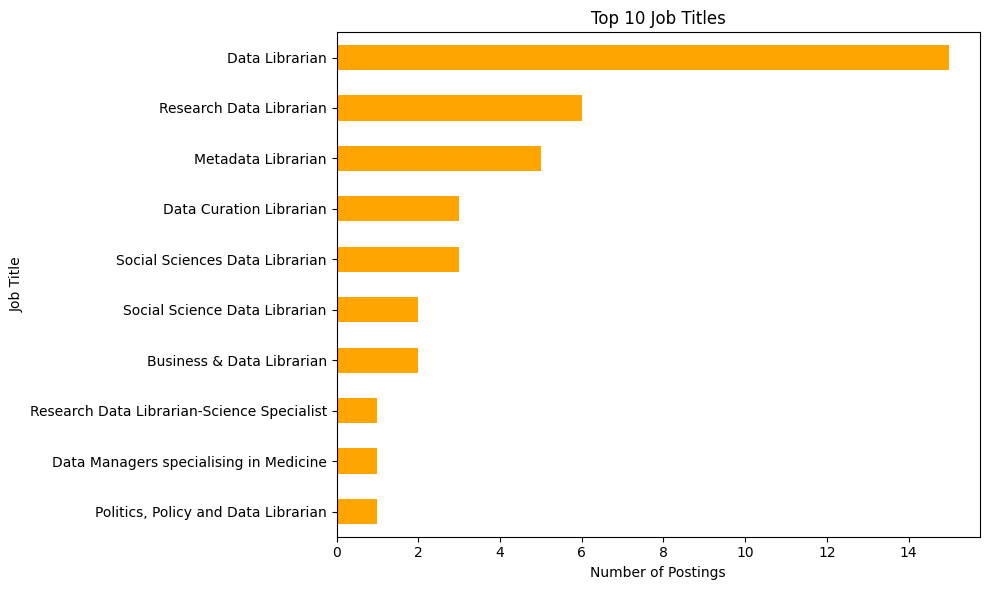

In [ ]:
import matplotlib.pyplot as plt

top_titles = filtered_jobs['Job Title'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_titles.plot(kind='barh', color='orange')
plt.title("Top 10 Job Titles")
plt.xlabel("Number of Postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


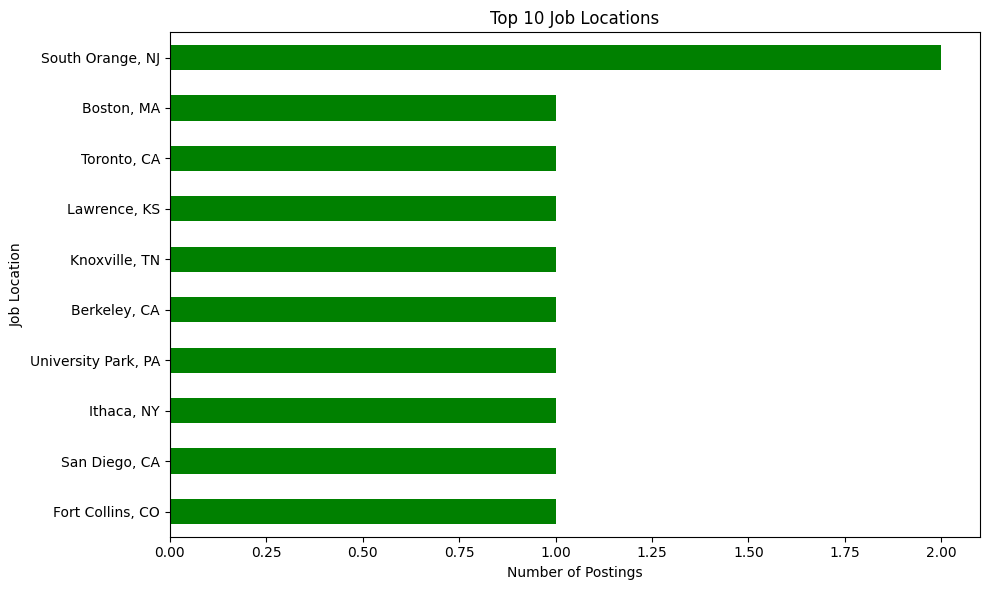

In [ ]:
if 'Job Location' in filtered_jobs.columns:
    top_locations = filtered_jobs['Job Location'].dropna().value_counts().head(10)

    plt.figure(figsize=(10, 6))
    top_locations.plot(kind='barh', color='green')
    plt.title("Top 10 Job Locations")
    plt.xlabel("Number of Postings")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [ ]:
filtered_jobs.to_csv("./iassist_jobs.csv")

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("./data_jobs.csv")

In [ ]:
data

,positionName,salary,jobType/0,jobType/1,company,location,rating,reviewsCount,url,companyInfo/companyDescription,companyInfo/companyLogo,companyInfo/companySize,companyInfo/companySize/max,companyInfo/companySize/min,companyInfo/indeedUrl,companyInfo/rating,companyInfo/reviewCount,companyInfo/url
0,Gallery Archivist,NaN,Full-time,NaN,Fisk University,"Nashville, TN 37208",3.8,45,https://www.indeed.com/viewjob?jk=c3f3f23f21c3...,Fisk University is a historically black univer...,https://d2q79iu7y748jz.cloudfront.net/s/_squar...,NaN,500.0,201.0,https://www.indeed.com/cmp/Fisk-University,3.8,45.0,http://www.fisk.edu/
1,"Director, Global Library Services","$174,500 - $274,230 a year",Full-time,NaN,Takeda Pharmaceutical,"Boston, MA",3.7,1758,https://www.indeed.com/viewjob?jk=fd85f6051cda...,"Takeda is a patient-focused, values-based, R&D...",https://d2q79iu7y748jz.cloudfront.net/s/_squar...,NaN,NaN,10000.0,https://www.indeed.com/cmp/Takeda-Pharmaceuticals,3.7,1758.0,https://www.takeda.com/
2,Executive Admin/Technical Writer,NaN,Full-time,NaN,Banner Quality Management Inc,"Odon, IN 47562",0.0,0,https://www.indeed.com/viewjob?jk=5436127b4855...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Modeler,$60 an hour,NaN,NaN,EMERGE SOLUTIONS GROUP LLC,"Ellicott City, MD 21042",4.7,3,https://www.indeed.com/viewjob?jk=2728fd132b6f...,NaN,NaN,NaN,NaN,NaN,https://www.indeed.com/cmp/Emerge-Solutions-Gr...,4.7,3.0,NaN
4,McAdory HS - Librarian,"$51,148 - $98,764 a year",Full-time,NaN,Jefferson County Board of Education,"Birmingham, AL",4.0,89,https://www.indeed.com/viewjob?jk=8d64ddde6d26...,NaN,NaN,NaN,5000.0,1001.0,https://www.indeed.com/cmp/Jefferson-County-Bo...,4.0,89.0,https://www.jefcoed.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,Digital Teacher Librarian (DTL),"$55,256.00 - $74,031.50 a year",Full-time,NaN,Jeffco Public Schools,"Lakewood, CO 80226",3.6,251,https://www.indeed.com/viewjob?jk=e8f5112c86e4...,NaN,https://d2q79iu7y748jz.cloudfront.net/s/_squar...,NaN,NaN,10000.0,https://www.indeed.com/cmp/Jeffco-Public-Schools,3.6,251.0,http://www.jeffcopublicschools.org
197,Associate Dean of Libraries Information Techno...,"From $150,000 a year",Full-time,NaN,University of Wisconsin–Madison,"Madison, WI 53706",4.4,513,https://www.indeed.com/viewjob?jk=79128519504d...,"Work with purpose, make an impact, and grow yo...",https://d2q79iu7y748jz.cloudfront.net/s/_squar...,NaN,NaN,10000.0,https://www.indeed.com/cmp/University-of-Wisco...,4.4,513.0,https://jobs.wisc.edu
198,"LIBRARIAN, PART-TIME (ALLEGHENY 6-8)","$50,129 a year",Part-time,NaN,Pittsburgh Public Schools,United States,3.2,131,https://www.indeed.com/viewjob?jk=117740e163c1...,Pittsburgh Public Schools is the public school...,https://d2q79iu7y748jz.cloudfront.net/s/_logo/...,NaN,10000.0,5001.0,https://www.indeed.com/cmp/Pittsburgh-Public-S...,3.2,131.0,http://www.pghboe.net
199,Circulation Assistant (Part Time),NaN,Part-time,NaN,Laramie County Library System,"Cheyenne, WY 82001",5.0,4,https://www.indeed.com/viewjob?jk=fdd59cab52d4...,NaN,NaN,NaN,NaN,NaN,https://www.indeed.com/cmp/Laramie-County-Libr...,5.0,4.0,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   positionName                    201 non-null    object 
 1   salary                          143 non-null    object 
 2   jobType/0                       169 non-null    object 
 3   jobType/1                       11 non-null     object 
 4   company                         201 non-null    object 
 5   location                        201 non-null    object 
 6   rating                          201 non-null    float64
 7   reviewsCount                    201 non-null    int64  
 8   url                             201 non-null    object 
 9   companyInfo/companyDescription  102 non-null    object 
 10  companyInfo/companyLogo         141 non-null    object 
 11  companyInfo/companySize         0 non-null      float64
 12  companyInfo/companySize/max     113 

In [ ]:
cols_to_drop = [
    "companyInfo/companyLogo",
    "companyInfo/companySize",
    "companyInfo/companySize/max",
    "companyInfo/reviewCount",
    "rating",
    "reviewsCount",
    "companyInfo/companySize/min",
    "companyInfo/indeedUrl",
    "companyInfo/companyDescription",
    "jobType/1",
    "companyInfo/url"
]

data = data.drop(columns=cols_to_drop)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   positionName        201 non-null    object 
 1   salary              143 non-null    object 
 2   jobType/0           169 non-null    object 
 3   company             201 non-null    object 
 4   location            201 non-null    object 
 5   url                 201 non-null    object 
 6   companyInfo/rating  177 non-null    float64
dtypes: float64(1), object(6)
memory usage: 11.1+ KB


In [ ]:
data = data.rename(columns={
    "positionName": "Job Title",
    "salary": "Salary",
    "jobType/0": "Employment Type",
    "company": "Company Name",
    "location": "Job Location",
    "url": "Job URL",
    "companyInfo/rating": "Company Rating"
})

In [ ]:
data.head()

,Job Title,Salary,Employment Type,Company Name,Job Location,Job URL,Company Rating
0,Gallery Archivist,NaN,Full-time,Fisk University,"Nashville, TN 37208",https://www.indeed.com/viewjob?jk=c3f3f23f21c3...,3.8
1,"Director, Global Library Services","$174,500 - $274,230 a year",Full-time,Takeda Pharmaceutical,"Boston, MA",https://www.indeed.com/viewjob?jk=fd85f6051cda...,3.7
2,Executive Admin/Technical Writer,NaN,Full-time,Banner Quality Management Inc,"Odon, IN 47562",https://www.indeed.com/viewjob?jk=5436127b4855...,NaN
3,Data Modeler,$60 an hour,NaN,EMERGE SOLUTIONS GROUP LLC,"Ellicott City, MD 21042",https://www.indeed.com/viewjob?jk=2728fd132b6f...,4.7
4,McAdory HS - Librarian,"$51,148 - $98,764 a year",Full-time,Jefferson County Board of Education,"Birmingham, AL",https://www.indeed.com/viewjob?jk=8d64ddde6d26...,4.0


In [ ]:
pattern = "librarian"
filtered_jobs = data[data['Job Title'].str.contains(pattern, case=False, na=False)]

In [ ]:
final_data = data[data["Job Title"].str.contains(r"(librarian|research)", case=False, na=False)]

/var/folders/xl/vfkbjv915zj70457rvb3m58w0000gn/T/ipykernel_89644/2875651729.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  final_data = data[data["Job Title"].str.contains(r"(librarian|research)", case=False, na=False)]


In [ ]:
final_data

,Job Title,Salary,Employment Type,Company Name,Job Location,Job URL,Company Rating
4,McAdory HS - Librarian,"$51,148 - $98,764 a year",Full-time,Jefferson County Board of Education,"Birmingham, AL",https://www.indeed.com/viewjob?jk=8d64ddde6d26...,4.0
7,CHILDRENS LIBRARIAN,NaN,Full-time,Cleveland Public Library,"Cleveland, OH 44114",https://www.indeed.com/viewjob?jk=8550a8e23c95...,4.2
8,Office Support Specialist (Law Librarian) 2025...,$18.56 an hour,Full-time,State of Wyoming,"Torrington, WY",https://www.indeed.com/viewjob?jk=6372db947b76...,3.6
10,Research & Training Librarian,"$85,000 - $100,000 a year",Full-time,Fisher & Phillips LLP,Remote,https://www.indeed.com/viewjob?jk=0144d4a89b8d...,3.4
15,Serials & Acquisitions Librarian,"$54,533 - $68,174 a year",Full-time,Radford University,"Radford, VA",https://www.indeed.com/viewjob?jk=42445c98aaa7...,4.1
16,Access Services and Collections Management Lib...,"$45,000 a year",Full-time,Cleveland Museum of Art,"Cleveland, OH 44106",https://www.indeed.com/viewjob?jk=7434321942e0...,3.6
18,LAC - Publishing Librarian,NaN,Full-time,Library Systems & Services LLC,"Gaithersburg, MD 20899",https://www.indeed.com/viewjob?jk=969eda778b55...,4.1
24,Resource Management & Discovery Librarian,NaN,Full-time,Texas A&M University - San Antonio,"San Antonio, TX 78224",https://www.indeed.com/viewjob?jk=788686a509a2...,3.8
39,Public Services Student Assistant - Spencer Re...,$11 an hour,NaN,University of Kansas,"Lawrence, KS 66045",https://www.indeed.com/viewjob?jk=036992f0e1b3...,4.2
42,Student Success Librarian (9+3),"$60,000 - $73,333 a year",NaN,State of South Carolina,"Spartanburg, SC 29303",https://www.indeed.com/viewjob?jk=49cfb4f35caf...,2.9


In [ ]:
final_data.to_csv("./final_data.csv", index=False)

In [ ]:
filtered_jobs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56 entries, 4 to 200
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   positionName                    56 non-null     object 
 1   salary                          41 non-null     object 
 2   jobType/0                       51 non-null     object 
 3   jobType/1                       3 non-null      object 
 4   company                         56 non-null     object 
 5   location                        56 non-null     object 
 6   rating                          56 non-null     float64
 7   reviewsCount                    56 non-null     int64  
 8   url                             56 non-null     object 
 9   companyInfo/companyDescription  23 non-null     object 
 10  companyInfo/companyLogo         38 non-null     object 
 11  companyInfo/companySize         0 non-null      float64
 12  companyInfo/companySize/max     35 no

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://iassistdata.org/jobs-repository/"
headers = {
    "User-Agent": "Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Mobile Safari/537.36"
}

web_data = requests.get(url, headers=headers)
soup = BeautifulSoup(web_data.content, features="html.parser")

# Find all job posting list items
li_items = soup.find_all('li', class_='alternate')
job_url = []
# For each job, extract the link to the detail page
for li in li_items:
    a_tag = li.find('a')
    if a_tag and 'href' in a_tag.attrs:
        job_title = a_tag.get_text(strip=True)
        job_url.append(a_tag['href'])


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/131.0.0.0 Safari/537.36"
}

results = []

# Define qualification keyword pattern
QUAL_PATTERN = r"(master|phd|doctorate|degree|ala|professor|instructor|bachelor)"

def split_edu_experience(text):
    """Split Education/Experience text into Qualification and Skills"""
    if not text:
        return None, None

    parts = [p.strip() for p in text.split(";") if p.strip()]

    qualifications = []
    skills = []

    for p in parts:
        if re.search(QUAL_PATTERN, p, re.IGNORECASE):
            qualifications.append(p)
        else:
            skills.append(p)

    qualification_text = "; ".join(qualifications) if qualifications else None
    skills_text = "; ".join(skills) if skills else None

    return qualification_text, skills_text


for jobs in job_url:  # job_url is your list of posting URLs
    response = requests.get(jobs, headers=headers, timeout=10)
    if response.status_code != 200:
        print(f"❌ Skipped {jobs}")
        continue

    soup = BeautifulSoup(response.content, "html.parser")

    # --- Job Title ---
    job_title_tag = soup.find("h1")
    job_title = job_title_tag.get_text(strip=True) if job_title_tag else None

    # --- Employer ---
    employer = None
    employer_strong = soup.find("strong", string=lambda x: x and "Employer:" in x)
    if employer_strong:
        employer = employer_strong.parent.get_text(strip=True).replace("Employer:", "").strip()

    # --- Employer URL ---
    employer_url = None
    employer_url_strong = soup.find("strong", string=lambda x: x and "Employer URL:" in x)
    if employer_url_strong:
        link = employer_url_strong.find_next("a")
        employer_url = link["href"] if link else None

    # --- Posted Date ---
    posted_date = None
    posted_strong = soup.find("strong", string=lambda x: x and "Posted to IASSIST on:" in x)
    if posted_strong:
        posted_date = posted_strong.parent.get_text(strip=True).replace("Posted to IASSIST on:", "").strip()

    # --- Salary / Benefits ---
    salary = None
    comp_strong = soup.find("strong", string=lambda x: x and ("Salary" in x or "Benefits" in x))
    if comp_strong:
        next_p = comp_strong.parent.find_next_sibling("p")
        salary = next_p.get_text(strip=True) if next_p else None

    # --- Job Location ---
    job_location = None
    location_strong = soup.find("strong", string=lambda x: x and "Job Location" in x)
    if location_strong:
        next_p = location_strong.find_parent().find_next_sibling("p")
        job_location = next_p.get_text(strip=True) if next_p else None

    # --- Education / Experience ---
    edu_text = None
    edu = []
    qual_headers = soup.find_all("strong", string=lambda x: x and ("Education" in x or "Experience" in x or "Qualifications" in x))
    for header in qual_headers:
        next_ul = header.find_parent().find_next_sibling("ul")
        if next_ul:
            for li in next_ul.find_all("li"):
                edu.append(li.get_text(strip=True))
    edu_text = "; ".join(edu) if edu else None

    # --- Split Education/Experience into Qualification + Skills ---
    qualification, extracted_skills = split_edu_experience(edu_text)

    # --- Store results ---
    results.append({
        "Job Title": job_title,
        "Employer": employer,
        "Employer URL": employer_url,
        "Posted Date": posted_date,
        "Salary": salary,
        "Job Location": job_location,
        "Education/Experience": edu_text,
        "Qualification": qualification,
        "Skills": extracted_skills,
        "Source URL": jobs
    })


In [ ]:

# Convert to DataFrame
df = pd.DataFrame(results)

In [ ]:
df

,Job Title,Employer,Employer URL,Posted Date,Salary,Job Location,Education/Experience,Qualification,Skills,Source URL
0,Data Services Specialist,Georgia State University,https://gsu.edu/,2025-07-03,"$68,900 – $81,750","Atlanta, GA",Librarian Instructor – no experience required....,Librarian Instructor – no experience required....,Ability in IBM SPSS Statistics software (both ...,https://iassistdata.org/jobs-repository/2025-0...
1,Assistant or Associate Business Information & ...,Colorado State University,https://colostate.edu/,2025-06-25,"Assistant Rank: $67,000-$74,000; Associate Ran...","Fort Collins, CO",Candidates must have ONE of the following educ...,Candidates must have ONE of the following educ...,Demonstrated ability to explain and/or teach c...,https://iassistdata.org/jobs-repository/2025-0...
2,Social Science Librarian,Georgia State University,https://gsu.edu/,2025-06-25,"$61,100 - $72,600, dependent on experience, ed...","Atlanta, GA",Experience providing in-person or online instr...,Master’s degree in library/information science...,Experience providing in-person or online instr...,https://iassistdata.org/jobs-repository/2025-0...
3,Business and Social Sciences Librarian,"University of California, Berkeley",https://berkeley.edu/,2025-06-17,The UC academic salary scales set the minimum ...,"Berkeley, CA",Advanced degree.,Advanced degree.,None,https://iassistdata.org/jobs-repository/2025-0...
4,Manager of Commons Events & Programming,Princeton University,https://princeton.edu/,2025-06-14,"$87,000 to $96,000","Princeton, NJ",Bachelor’s degree; 3 years experience planning...,Bachelor’s degree; Excellent interpersonal and...,"3 years experience planning workshops, events,...",https://iassistdata.org/jobs-repository/2025-0...
...,...,...,...,...,...,...,...,...,...,...
961,Statistical Support Specialist,Yale University,http://www.yale.edu/,2005-05-06,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...
962,Numeric and Spatial Data Services Librarian,University of Michigan,http://www.lib.umich.edu/,2005-05-01,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...
963,Librarian for the Social Sciences,Harvard College Library,http://www.harvard.edu/,2005-03-30,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...
964,Tenure-track position: Data Librarian,"Leddy Library, University of Windsor",http://www.uwindsor.ca/library/leddy,2005-03-22,None,None,None,None,None,https://iassistdata.org/jobs-repository/2005-0...


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/131.0.0.0 Safari/537.36"
}

results = []

for jobs in job_url:
    response = requests.get(jobs, headers=headers, timeout=10)
    if response.status_code != 200:
        print(f"❌ Skipped {jobs}")
        continue

    soup = BeautifulSoup(response.content, "html.parser")

    # --- Job Title ---
    job_title_tag = soup.find("h1")
    job_title = job_title_tag.get_text(strip=True) if job_title_tag else None

    # --- Employer ---
    employer_tag = soup.find("p", string=lambda x: x and "Employer:" in x)
    if employer_tag:
        employer = employer_tag.get_text(strip=True).replace("Employer:", "").strip()
    else:
        employer_strong = soup.find("strong", string=lambda x: x and "Employer:" in x)
        employer = employer_strong.parent.get_text(strip=True).replace("Employer:", "").strip() if employer_strong else None

    # --- Employer URL ---
    employer_url_tag = soup.find("p", string=lambda x: x and "Employer URL:" in x)
    if employer_url_tag:
        employer_url = employer_url_tag.find("a")["href"] if employer_url_tag.find("a") else None
    else:
        employer_url_strong = soup.find("strong", string=lambda x: x and "Employer URL:" in x)
        employer_url = employer_url_strong.find_next("a")["href"] if employer_url_strong and employer_url_strong.find_next("a") else None

    # --- Posted Date ---
    posted_date = None
    for strong in soup.find_all("strong"):
        if "Posted to IASSIST on:" in strong.get_text():
            posted_date = strong.parent.get_text(strip=True).replace("Posted to IASSIST on:", "").strip()
            break

    # --- Salary ---
    salary = None
    for strong in soup.find_all("strong"):
        if "Salary" in strong.get_text():
            next_p = strong.parent.find_next_sibling("p")
            if next_p:
                salary = next_p.get_text(strip=True)
                break

    # --- Necessary Skills ---
    necessary_skills = []
    necessary_skills_label = soup.find(lambda tag: tag.name == "p" and "Necessary Skills:" in tag.get_text())
    if necessary_skills_label:
        ul = necessary_skills_label.find_next_sibling("ul")
        if ul:
            necessary_skills = [li.get_text(strip=True) for li in ul.find_all("li")]

    # --- Preferred Skills ---
    preferred_skills = []
    preferred_skills_label = soup.find(lambda tag: tag.name == "p" and "Preferred Skills:" in tag.get_text())
    if preferred_skills_label:
        ul = preferred_skills_label.find_next_sibling("ul")
        if ul:
            preferred_skills = [li.get_text(strip=True) for li in ul.find_all("li")]

    # --- Education and Experience ---
    education_and_experience = []
    edu_exp_label = soup.find(lambda tag: tag.name == "p" and "Education and Experience" in tag.get_text())
    if edu_exp_label:
        ul = edu_exp_label.find_next_sibling("ul")
        if ul:
            education_and_experience = [li.get_text(strip=True) for li in ul.find_all("li")]

    # --- Combine and store ---
    results.append({
        "Job Title": job_title,
        "Employer": employer,
        "Employer URL": employer_url,
        "Salary": salary,
        "Posted Date": posted_date,
        "Education and Experience": "; ".join(education_and_experience) if education_and_experience else None,
        "Necessary Skills": "; ".join(necessary_skills) if necessary_skills else None,
        "Preferred Skills": "; ".join(preferred_skills) if preferred_skills else None,
        "Source URL": jobs
    })



In [ ]:
# Example: convert to DataFrame
df = pd.DataFrame(results)

In [ ]:
job_url

['https://iassistdata.org/jobs-repository/2025-07-03/',
 'https://iassistdata.org/jobs-repository/2025-06-25_1/',
 'https://iassistdata.org/jobs-repository/2025-06-25_2/',
 'https://iassistdata.org/jobs-repository/2025-06-17/',
 'https://iassistdata.org/jobs-repository/2025-06-14/',
 'https://iassistdata.org/jobs-repository/2025-05-14/',
 'https://iassistdata.org/jobs-repository/2025-03-19/',
 'https://iassistdata.org/jobs-repository/2025-03-17/',
 'https://iassistdata.org/jobs-repository/2025-03-13/',
 'https://iassistdata.org/jobs-repository/2025-03-05/',
 'https://iassistdata.org/jobs-repository/2025-03-04_2/',
 'https://iassistdata.org/jobs-repository/2025-03-04_1/',
 'https://iassistdata.org/jobs-repository/2025-02-26_1/',
 'https://iassistdata.org/jobs-repository/2025-02-26_2/',
 'https://iassistdata.org/jobs-repository/2025-02-26_3/',
 'https://iassistdata.org/jobs-repository/2025-02-12/',
 'https://iassistdata.org/jobs-repository/2025-02-10/',
 'https://iassistdata.org/jobs-rep

In [ ]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/131.0.0.0 Safari/537.36"
}

results = []

for jobs in job_url:
    response = requests.get(jobs, headers=headers, timeout=10)
    if response.status_code != 200:
        print(f"❌ Skipped {jobs}")
        continue

    soup = BeautifulSoup(response.content, "html.parser")

    # Extract fields by label
    # --- Job Title ---
    job_title_tag = soup.find("h1")
    job_title = job_title_tag.get_text(strip=True) if job_title_tag else None

    # --- Employer ---
    employer_tag = soup.find("p", string=lambda x: x and "Employer:" in x)
    if employer_tag:
        employer = employer_tag.get_text(strip=True).replace("Employer:", "").strip()
    else:
        # fallback if fonts are nested
        employer_strong = soup.find("strong", string=lambda x: x and "Employer:" in x)
        employer = employer_strong.parent.get_text(strip=True).replace("Employer:", "").strip() if employer_strong else None

    # --- Employer URL ---
    employer_url_tag = soup.find("p", string=lambda x: x and "Employer URL:" in x)
    if employer_url_tag:
        employer_url = employer_url_tag.find("a")["href"] if employer_url_tag.find("a") else None
    else:
        # fallback
        employer_url_strong = soup.find("strong", string=lambda x: x and "Employer URL:" in x)
        employer_url = employer_url_strong.find_next("a")["href"] if employer_url_strong and employer_url_strong.find_next("a") else None

    # --- Necessary Skills ---
    skills_section = soup.find("p", string=lambda x: x and "Necessary Skills:" in x)
    skills = []
    if skills_section:
        ul = skills_section.find_next("ul")
        if ul:
            skills = [li.get_text(strip=True) for li in ul.find_all("li")]
    skills_text = "; ".join(skills) if skills else None

    # --- Salary ---
    salary_section = soup.find("p", string=lambda x: x and "Salary" in x)
    salary = None
    if salary_section:
        # salary info is usually in the next <p>
        salary_info = salary_section.find_next("p")
        if salary_info:
            salary = salary_info.get_text(strip=True)

    posted_date_tag = soup.find("p", string=lambda x: x and "Posted to IASSIST on:" in x)
    posted_date = None
    if posted_date_tag:
        posted_date = posted_date_tag.get_text(strip=True).replace("Posted to IASSIST on:", "").strip()

    # Store results
    results.append({
            "Job Title": job_title,
            "Employer": employer,
            "Employer URL": employer_url,
            "Salary": salary,
            "Skills": skills_text,
            "Date": posted_date,
            "Source URL": jobs
    })


KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(results)

In [ ]:
df

,Job Title,Employer,Employer URL,Salary,Skills,Date,Source URL
0,Data Services Specialist,Georgia State University,https://gsu.edu/,"$68,900 – $81,750",None,None,https://iassistdata.org/jobs-repository/2025-0...
1,Assistant or Associate Business Information & ...,Colorado State University,https://colostate.edu/,"Assistant Rank: $67,000-$74,000; Associate Ran...",None,None,https://iassistdata.org/jobs-repository/2025-0...
2,Social Science Librarian,Georgia State University,https://gsu.edu/,"$61,100 - $72,600, dependent on experience, ed...",None,None,https://iassistdata.org/jobs-repository/2025-0...
3,Business and Social Sciences Librarian,"University of California, Berkeley",https://berkeley.edu/,The UC academic salary scales set the minimum ...,None,None,https://iassistdata.org/jobs-repository/2025-0...
4,Manager of Commons Events & Programming,Princeton University,https://princeton.edu/,"$87,000 to $96,000",None,None,https://iassistdata.org/jobs-repository/2025-0...
...,...,...,...,...,...,...,...
134,Data Librarian (Librarian II or III),"University of Toronto Libraries (Toronto, ON, ...",http://www.library.utoronto.ca/home/,Additional Information\nNOTE: This position is...,None,None,https://iassistdata.org/jobs-repository/2010-0...
135,Data Librarian - Three Year Term,University of Saskatchewan,http://www.usask.ca,Archived on:2010-02-22,None,None,https://iassistdata.org/jobs-repository/2010-0...
136,Data Repository Architect,North Carolina State University Libraries,http://www.lib.ncsu.edu/,The Libraries offers highly competitive salari...,None,None,https://iassistdata.org/jobs-repository/2006-1...
137,Documents/Data Services Librarian,UNC-Greensboro Libraries,http://library.uncg.edu/,Preferred Qualifications:,None,None,https://iassistdata.org/jobs-repository/2006-1...


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/131.0.0.0 Safari/537.36"
}

results = []

for jobs in job_url:
    response = requests.get(jobs, headers=headers, timeout=10)
    if response.status_code != 200:
        print(f"❌ Skipped {jobs}")
        continue

    soup = BeautifulSoup(response.content, "html.parser")

    # --- Job Title ---
    job_title_tag = soup.find("h1")
    job_title = job_title_tag.get_text(strip=True) if job_title_tag else None

    # --- Employer ---
    employer_tag = soup.find("p", string=lambda x: x and "Employer:" in x)
    if employer_tag:
        employer = employer_tag.get_text(strip=True).replace("Employer:", "").strip()
    else:
        employer_strong = soup.find("strong", string=lambda x: x and "Employer:" in x)
        employer = employer_strong.parent.get_text(strip=True).replace("Employer:", "").strip() if employer_strong else None

    # --- Employer URL ---
    employer_url_tag = soup.find("p", string=lambda x: x and "Employer URL:" in x)
    if employer_url_tag:
        employer_url = employer_url_tag.find("a")["href"] if employer_url_tag.find("a") else None
    else:
        employer_url_strong = soup.find("strong", string=lambda x: x and "Employer URL:" in x)
        employer_url = employer_url_strong.find_next("a")["href"] if employer_url_strong and employer_url_strong.find_next("a") else None

    # --- Necessary Skills ---
    skills = []
    skills_label = soup.find(lambda tag: tag.name=="p" and "Necessary Skills:" in tag.get_text())
    if skills_label:
        # Get the <ul> after the label
        ul = skills_label.find_next_sibling("ul")
        if ul:
            # Extract text from each <li>
            for li in ul.find_all("li"):
                skills.append(li.get_text(strip=True))
    skills_text = "; ".join(skills) if skills else None

    posted_date = None
    for strong in soup.find_all("strong"):
        if "Posted to IASSIST on:" in strong.get_text():
            posted_date = strong.parent.get_text(strip=True).replace("Posted to IASSIST on:", "").strip()
            break

# --- Salary ---
    salary = None
    for strong in soup.find_all("strong"):
        if "Salary" in strong.get_text():
        # salary is usually in the next <p> after this <strong>
            next_p = strong.parent.find_next_sibling("p")
            if next_p:
                salary = next_p.get_text(strip=True)
                break

    # Store results
    results.append({
        "Job Title": job_title,
        "Employer": employer,
        "Employer URL": employer_url,
        "Salary": salary,
        "Skills": skills_text,
        "Posted Date": posted_date,
        "Source URL": jobs
    })